# Exploratory Data Analysis

## Palm Oil Waste Prediction Using Stacking Ensemble Machine Learning

This notebook presents the exploratory data analysis (EDA) conducted for a machine learning project on predicting palm oil waste quantities in Nigeria.

The analysis focuses on understanding the structure, quality, distribution, temporal patterns, and relationships within the dataset before machine learning model development.

### Analysis Objectives

The exploratory analysis will examine:

- Dataset structure and data types
- Missing values and duplicate observations
- Descriptive statistics
- Fresh Fruit Bunch (FFB) production patterns
- Palm oil waste quantities
- Temporal trends from 1964 to 2024
- Environmental variables
- Correlations between predictor and target variables

### Target Variables

The four palm oil waste streams investigated are:

- Empty Fruit Bunches (EFB)
- Palm Kernel Shells (PKS)
- Palm Oil Mill Effluent (POME)
- Mesocarp Fibre (MF)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Load the Dataset

In [2]:
df = pd.read_csv("../data/palm_oil_waste_dataset_1964_2024.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


## 2. Initial Data Inspection

Before conducting the exploratory analysis, the dataset is inspected to understand its dimensions, variables, data types, and overall structure.

In [3]:
df.shape

(732, 14)

In [4]:
df.head()

,Year,Month,Month_Number,Quarter,FFB_1000MT,EFB_1000MT,PKS_1000MT,POME_1000MT,Mesocarp_Fibre_1000MT,Avg_Temperature_C,Rainfall_mm,Humidity_pct,Wind_Speed_ms,Solar_Radiation_Wm2
0,1964,Jan,1,Q1,26.85,5.907,1.611,17.453,3.491,27.27,45.84,82.20,2.00,187.66
1,1964,Feb,2,Q1,32.22,7.088,1.933,20.943,4.189,28.28,67.60,81.26,2.11,192.43
2,1964,Mar,3,Q1,53.70,11.814,3.222,34.905,6.981,28.26,154.10,84.20,2.20,181.76
3,1964,Apr,4,Q2,69.81,15.358,4.189,45.377,9.075,28.22,221.79,87.13,2.09,167.18
4,1964,May,5,Q2,75.18,16.540,4.511,48.867,9.773,27.24,308.64,88.19,2.00,157.86


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Year                   732 non-null    int64  
 1   Month                  732 non-null    str    
 2   Month_Number           732 non-null    int64  
 3   Quarter                732 non-null    str    
 4   FFB_1000MT             732 non-null    float64
 5   EFB_1000MT             732 non-null    float64
 6   PKS_1000MT             732 non-null    float64
 7   POME_1000MT            732 non-null    float64
 8   Mesocarp_Fibre_1000MT  732 non-null    float64
 9   Avg_Temperature_C      732 non-null    float64
 10  Rainfall_mm            732 non-null    float64
 11  Humidity_pct           732 non-null    float64
 12  Wind_Speed_ms          732 non-null    float64
 13  Solar_Radiation_Wm2    732 non-null    float64
dtypes: float64(10), int64(2), str(2)
memory usage: 80.2 KB


## 3. Data Quality Assessment

The dataset is assessed for missing values, duplicate records, and temporal completeness before further analysis.

In [6]:
# Check for missing values
df.isnull().sum()

Year                     0
Month                    0
Month_Number             0
Quarter                  0
FFB_1000MT               0
EFB_1000MT               0
PKS_1000MT               0
POME_1000MT              0
Mesocarp_Fibre_1000MT    0
Avg_Temperature_C        0
Rainfall_mm              0
Humidity_pct             0
Wind_Speed_ms            0
Solar_Radiation_Wm2      0
dtype: int64

In [7]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

In [8]:
# Check for duplicate year-month observations
df.duplicated(subset=["Year", "Month_Number"]).sum()

np.int64(0)

In [9]:
print("Start year:", df["Year"].min())
print("End year:", df["Year"].max())
print("Number of years:", df["Year"].nunique())

Start year: 1964
End year: 2024
Number of years: 61


In [10]:
months_per_year = df.groupby("Year")["Month_Number"].nunique()

months_per_year.value_counts()

Month_Number
12    61
Name: count, dtype: int64

## 4. Descriptive Statistics

Descriptive statistics are examined to understand the central tendency, variability, and range of the numerical variables in the dataset.

In [11]:
df.describe().round(2)

,Year,Month_Number,FFB_1000MT,EFB_1000MT,PKS_1000MT,POME_1000MT,Mesocarp_Fibre_1000MT,Avg_Temperature_C,Rainfall_mm,Humidity_pct,Wind_Speed_ms,Solar_Radiation_Wm2
count,732.00,732.00,732.00,732.00,732.00,732.00,732.00,732.00,732.00,732.00,732.00,732.00
mean,1994.00,6.50,60.81,13.38,3.65,39.53,7.91,26.84,225.45,86.88,1.96,165.84
std,17.62,3.45,35.05,7.71,2.10,22.78,4.56,1.12,124.97,3.56,0.14,18.17
min,1964.00,1.00,13.20,2.90,0.79,8.58,1.72,24.80,34.40,80.30,1.65,136.08
25%,1979.00,3.75,34.20,7.52,2.05,22.23,4.45,25.82,103.20,83.38,1.85,148.65
50%,1994.00,6.50,52.90,11.64,3.17,34.39,6.88,27.24,249.05,87.85,2.00,163.57
75%,2009.00,9.25,76.85,16.91,4.61,49.95,9.99,27.72,334.12,90.20,2.06,183.11
max,2024.00,12.00,210.00,46.20,12.60,136.50,27.30,28.70,456.70,92.10,2.27,198.14


In [12]:
production_variables = [
    "FFB_1000MT",
    "EFB_1000MT",
    "PKS_1000MT",
    "POME_1000MT",
    "Mesocarp_Fibre_1000MT"
]

df[production_variables].describe().round(2)

,FFB_1000MT,EFB_1000MT,PKS_1000MT,POME_1000MT,Mesocarp_Fibre_1000MT
count,732.00,732.00,732.00,732.00,732.00
mean,60.81,13.38,3.65,39.53,7.91
std,35.05,7.71,2.10,22.78,4.56
min,13.20,2.90,0.79,8.58,1.72
25%,34.20,7.52,2.05,22.23,4.45
50%,52.90,11.64,3.17,34.39,6.88
75%,76.85,16.91,4.61,49.95,9.99
max,210.00,46.20,12.60,136.50,27.30


environmental_variables = [
    "Avg_Temperature_C",
    "Rainfall_mm",
    "Humidity_pct",
    "Wind_Speed_ms",
    "Solar_Radiation_Wm2"
]

df[environmental_variables].describe().round(2)

### Key Observations

- The dataset contains 732 monthly observations covering the period from 1964 to 2024.
- Average monthly Fresh Fruit Bunch (FFB) production was 60.81 thousand metric tonnes, ranging from 13.20 to 210.00 thousand metric tonnes.
- Among the four waste streams, POME had the highest average monthly quantity (39.53 thousand metric tonnes), followed by EFB (13.38), Mesocarp Fibre (7.91), and PKS (3.65).
- For FFB and all four waste streams, the mean exceeds the median, indicating that higher-value observations influence the overall averages.
- Average temperature was 26.84°C, while average relative humidity was 86.88%.
- Rainfall showed substantial variability, ranging from 34.40 mm to 456.70 mm, with a mean of 225.45 mm.
- Wind speed and solar radiation showed comparatively lower variability across the dataset.

These descriptive statistics provide an initial understanding of the scale and variability of the production, waste, and environmental variables. Further visual analysis is required to examine their temporal patterns and relationships.

## 5. Temporal Analysis

A monthly date variable is created from the year and month fields to support chronological analysis of production and waste quantities.

In [13]:
df["Date"] = pd.to_datetime(
    dict(
        year=df["Year"],
        month=df["Month_Number"],
        day=1
    )
)

df[["Year", "Month", "Month_Number", "Date"]].head()

,Year,Month,Month_Number,Date
0,1964,Jan,1,1964-01-01
1,1964,Feb,2,1964-02-01
2,1964,Mar,3,1964-03-01
3,1964,Apr,4,1964-04-01
4,1964,May,5,1964-05-01


### 5.1 Fresh Fruit Bunch Production Over Time

The monthly Fresh Fruit Bunch (FFB) production series is visualised to examine long-term trends and changes in production between 1964 and 2024.

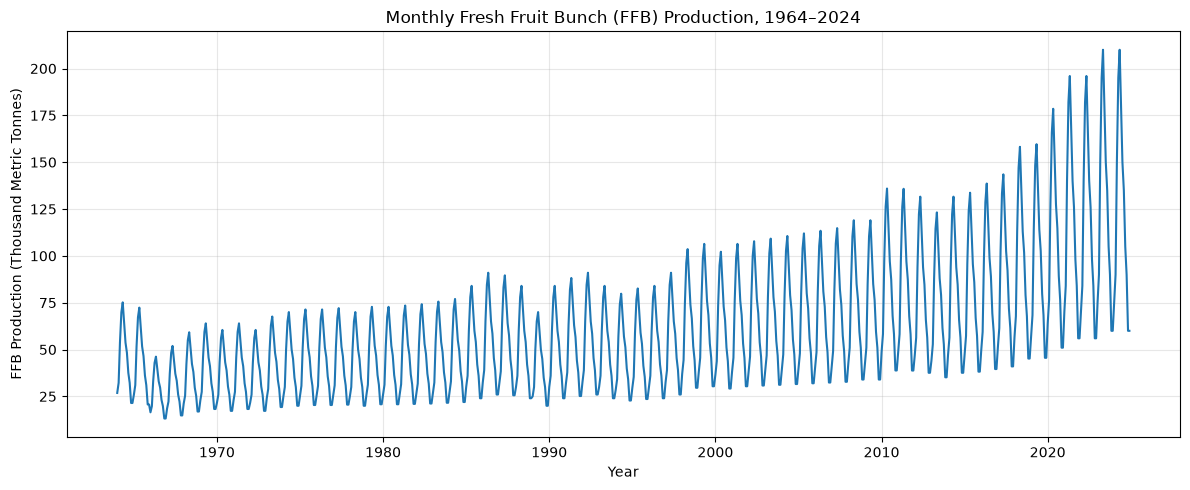

In [14]:
plt.figure(figsize=(12, 5))

plt.plot(df["Date"], df["FFB_1000MT"])

plt.title("Monthly Fresh Fruit Bunch (FFB) Production, 1964–2024")
plt.xlabel("Year")
plt.ylabel("FFB Production (Thousand Metric Tonnes)")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Key Observation

The monthly FFB production series shows a clear long-term upward trend between 1964 and 2024, alongside a pronounced recurring seasonal pattern. Production levels generally increase over time, with particularly high values occurring in the later years of the dataset.

The magnitude of the seasonal fluctuations also increases as production rises, suggesting that the variability in monthly production is associated with the overall production level. These temporal characteristics support the use of time-aware validation methods rather than random train-test splitting.

### 5.2 Annual FFB Production Trend

Monthly FFB production is aggregated by year to provide a clearer view of the long-term production trend.

In [15]:
annual_ffb = (
    df.groupby("Year")["FFB_1000MT"]
      .mean()
      .reset_index()
)

annual_ffb.head()

,Year,FFB_1000MT
0,1964,44.750000
1,1965,43.083333
2,1966,27.500000
3,1967,30.916667
4,1968,35.250000


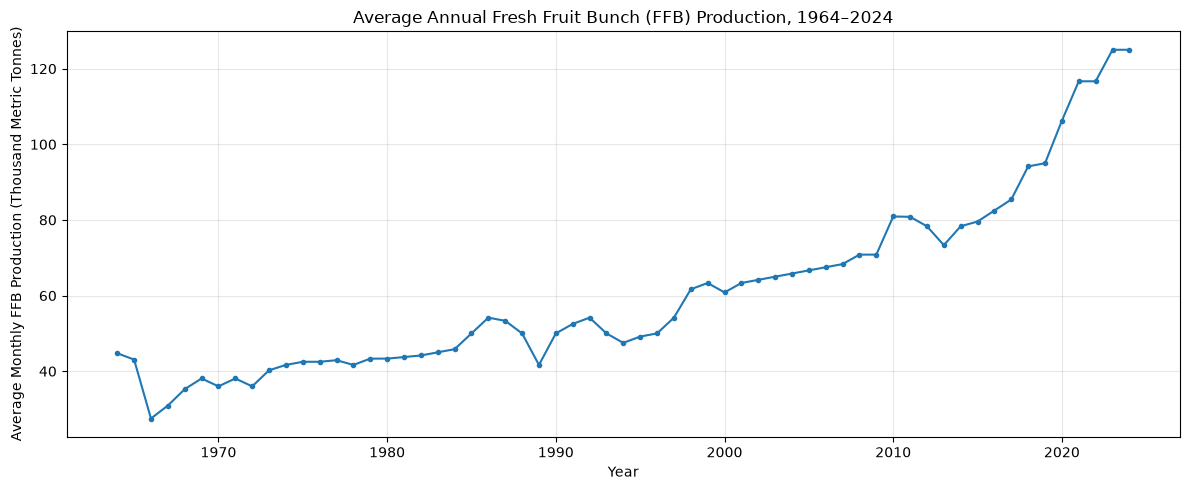

In [16]:
plt.figure(figsize=(12, 5))

plt.plot(
    annual_ffb["Year"],
    annual_ffb["FFB_1000MT"],
    marker="o",
    markersize=3
)

plt.title("Average Annual Fresh Fruit Bunch (FFB) Production, 1964–2024")
plt.xlabel("Year")
plt.ylabel("Average Monthly FFB Production (Thousand Metric Tonnes)")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Key Observation

The annual aggregation provides a clearer view of the long-term production trend. Average monthly FFB production generally increased between 1964 and 2024, although the series contains several periods of temporary decline and recovery.

Production growth becomes particularly pronounced toward the end of the study period, with the highest average monthly production levels occurring in the final years. This long-term trend indicates that production levels are not stationary across the full study period and reinforces the importance of preserving chronological order during model development and evaluation.

### 5.3 Monthly Production Pattern

Average FFB production is examined by calendar month to identify recurring seasonal patterns in the production series.

In [17]:
monthly_ffb = (
    df.groupby(["Month_Number", "Month"])["FFB_1000MT"]
      .mean()
      .reset_index()
      .sort_values("Month_Number")
)

monthly_ffb

,Month_Number,Month,FFB_1000MT
0,1,Jan,36.487705
1,2,Feb,43.785246
2,3,Mar,72.975410
3,4,Apr,94.868033
4,5,May,102.165574
5,6,Jun,87.570492
6,7,Jul,72.975410
7,8,Aug,65.677869
8,9,Sep,51.082787
9,10,Oct,43.785246


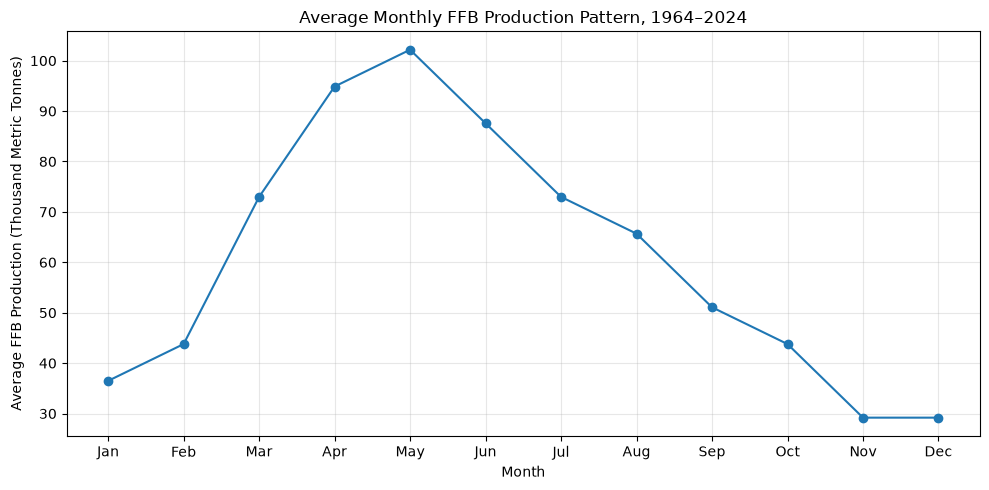

In [18]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_ffb["Month"],
    monthly_ffb["FFB_1000MT"],
    marker="o"
)

plt.title("Average Monthly FFB Production Pattern, 1964–2024")
plt.xlabel("Month")
plt.ylabel("Average FFB Production (Thousand Metric Tonnes)")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Key Observation

FFB production exhibits a pronounced seasonal pattern. Average production increases from January through the first half of the year, reaching its highest level in May, before declining progressively during the remaining months.

November and December record the lowest average production levels. The consistency of this monthly pattern indicates strong seasonality in the dataset and supports the inclusion of temporal variables such as month and quarter in the predictive modelling process.

## 6. Palm Oil Waste Analysis

The four target waste streams are examined to understand their quantities and temporal behaviour across the study period.

In [19]:
waste_variables = [
    "EFB_1000MT",
    "PKS_1000MT",
    "POME_1000MT",
    "Mesocarp_Fibre_1000MT"
]

average_waste = df[waste_variables].mean().sort_values(ascending=False)

average_waste

POME_1000MT              39.528367
EFB_1000MT               13.378831
Mesocarp_Fibre_1000MT     7.905680
PKS_1000MT                3.648768
dtype: float64

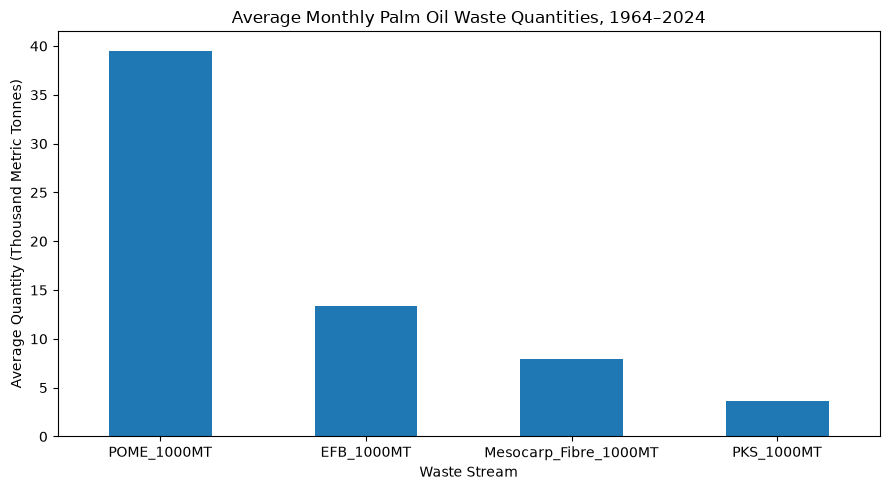

In [20]:
plt.figure(figsize=(9, 5))

average_waste.plot(kind="bar")

plt.title("Average Monthly Palm Oil Waste Quantities, 1964–2024")
plt.xlabel("Waste Stream")
plt.ylabel("Average Quantity (Thousand Metric Tonnes)")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### Key Observation

POME has the highest average monthly quantity among the four waste streams, followed by EFB, Mesocarp Fibre, and PKS.

The differences in magnitude reflect the conversion relationships used to derive the waste quantities from Fresh Fruit Bunch (FFB) production. Therefore, the waste streams are expected to exhibit strong relationships with FFB rather than behaving as completely independent quantities.

### 6.1 Relationship Between FFB Production and Waste Quantities

Because the waste quantities were derived from FFB production using conversion factors, the relationship between FFB and each target variable is examined explicitly.

In [21]:
ffb_waste_variables = [
    "FFB_1000MT",
    "EFB_1000MT",
    "PKS_1000MT",
    "POME_1000MT",
    "Mesocarp_Fibre_1000MT"
]

ffb_waste_correlation = df[ffb_waste_variables].corr()

ffb_waste_correlation.round(4)

,FFB_1000MT,EFB_1000MT,PKS_1000MT,POME_1000MT,Mesocarp_Fibre_1000MT
FFB_1000MT,1.0,1.0,1.0,1.0,1.0
EFB_1000MT,1.0,1.0,1.0,1.0,1.0
PKS_1000MT,1.0,1.0,1.0,1.0,1.0
POME_1000MT,1.0,1.0,1.0,1.0,1.0
Mesocarp_Fibre_1000MT,1.0,1.0,1.0,1.0,1.0


In [22]:
conversion_ratios = pd.DataFrame({
    "EFB / FFB": df["EFB_1000MT"] / df["FFB_1000MT"],
    "PKS / FFB": df["PKS_1000MT"] / df["FFB_1000MT"],
    "POME / FFB": df["POME_1000MT"] / df["FFB_1000MT"],
    "Mesocarp Fibre / FFB": (
        df["Mesocarp_Fibre_1000MT"] / df["FFB_1000MT"]
    )
})

conversion_ratios.describe().round(4)

,EFB / FFB,PKS / FFB,POME / FFB,Mesocarp Fibre / FFB
count,732.00,732.00,732.00,732.00
mean,0.22,0.06,0.65,0.13
std,0.00,0.00,0.00,0.00
min,0.22,0.06,0.65,0.13
25%,0.22,0.06,0.65,0.13
50%,0.22,0.06,0.65,0.13
75%,0.22,0.06,0.65,0.13
max,0.22,0.06,0.65,0.13


#### Key Observation: Target Dependence on FFB

The analysis reveals an approximately perfect linear relationship between FFB production and all four waste target variables. The waste quantities correspond to approximately 22% of FFB for EFB, 6% for PKS, 65% for POME, and 13% for Mesocarp Fibre.

This relationship is expected because the waste quantities were derived from FFB production using conversion factors. Consequently, FFB provides a strong deterministic signal for predicting the target variables.

This dependence is important when interpreting machine learning performance. High predictive accuracy from models that include FFB may partly reflect the underlying conversion relationships rather than relationships learned independently from the environmental and temporal predictors.

For this reason, model performance should be interpreted alongside sensitivity analysis excluding FFB and, where appropriate, a simple conversion-factor baseline.

In [23]:
for target in [
    "EFB_1000MT",
    "PKS_1000MT",
    "POME_1000MT",
    "Mesocarp_Fibre_1000MT"
]:
    correlation = df["FFB_1000MT"].corr(df[target])
    print(f"{target}: {correlation:.10f}")

EFB_1000MT: 0.9999999999
PKS_1000MT: 0.9999999988
POME_1000MT: 1.0000000000
Mesocarp_Fibre_1000MT: 0.9999999995


In [24]:
conversion_ratios.describe().round(8)

,EFB / FFB,PKS / FFB,POME / FFB,Mesocarp Fibre / FFB
count,732.000000,732.000000,732.000000,732.000000
mean,0.220000,0.060000,0.650001,0.130000
std,0.000004,0.000003,0.000003,0.000005
min,0.219976,0.059973,0.649981,0.129977
25%,0.220000,0.060000,0.650000,0.130000
50%,0.220000,0.060000,0.650000,0.130000
75%,0.220000,0.060000,0.650000,0.130000
max,0.220023,0.060018,0.650027,0.130027


## 7. Correlation Analysis

Correlation analysis is used to examine the linear relationships among production, waste, temporal, and environmental variables. Particular attention is given to the relationship between FFB and the four target waste streams.

In [25]:
correlation_variables = [
    "Year",
    "Month_Number",
    "FFB_1000MT",
    "EFB_1000MT",
    "PKS_1000MT",
    "POME_1000MT",
    "Mesocarp_Fibre_1000MT",
    "Avg_Temperature_C",
    "Rainfall_mm",
    "Humidity_pct",
    "Wind_Speed_ms",
    "Solar_Radiation_Wm2"
]

correlation_matrix = df[correlation_variables].corr()

correlation_matrix.round(2)

,Year,Month_Number,FFB_1000MT,EFB_1000MT,PKS_1000MT,POME_1000MT,Mesocarp_Fibre_1000MT,Avg_Temperature_C,Rainfall_mm,Humidity_pct,Wind_Speed_ms,Solar_Radiation_Wm2
Year,1.00,0.00,0.61,0.61,0.61,0.61,0.61,0.00,0.00,0.00,-0.00,-0.00
Month_Number,0.00,1.00,-0.26,-0.26,-0.26,-0.26,-0.26,-0.48,0.24,0.33,-0.46,-0.29
FFB_1000MT,0.61,-0.26,1.00,1.00,1.00,1.00,1.00,0.00,0.41,0.36,-0.00,-0.36
EFB_1000MT,0.61,-0.26,1.00,1.00,1.00,1.00,1.00,0.00,0.41,0.36,-0.00,-0.36
PKS_1000MT,0.61,-0.26,1.00,1.00,1.00,1.00,1.00,0.00,0.41,0.36,-0.00,-0.36
POME_1000MT,0.61,-0.26,1.00,1.00,1.00,1.00,1.00,0.00,0.41,0.36,-0.00,-0.36
Mesocarp_Fibre_1000MT,0.61,-0.26,1.00,1.00,1.00,1.00,1.00,0.00,0.41,0.36,-0.00,-0.36
Avg_Temperature_C,0.00,-0.48,0.00,0.00,0.00,0.00,0.00,1.00,-0.72,-0.79,0.97,0.83
Rainfall_mm,0.00,0.24,0.41,0.41,0.41,0.41,0.41,-0.72,1.00,0.97,-0.65,-0.94
Humidity_pct,0.00,0.33,0.36,0.36,0.36,0.36,0.36,-0.79,0.97,1.00,-0.76,-0.98


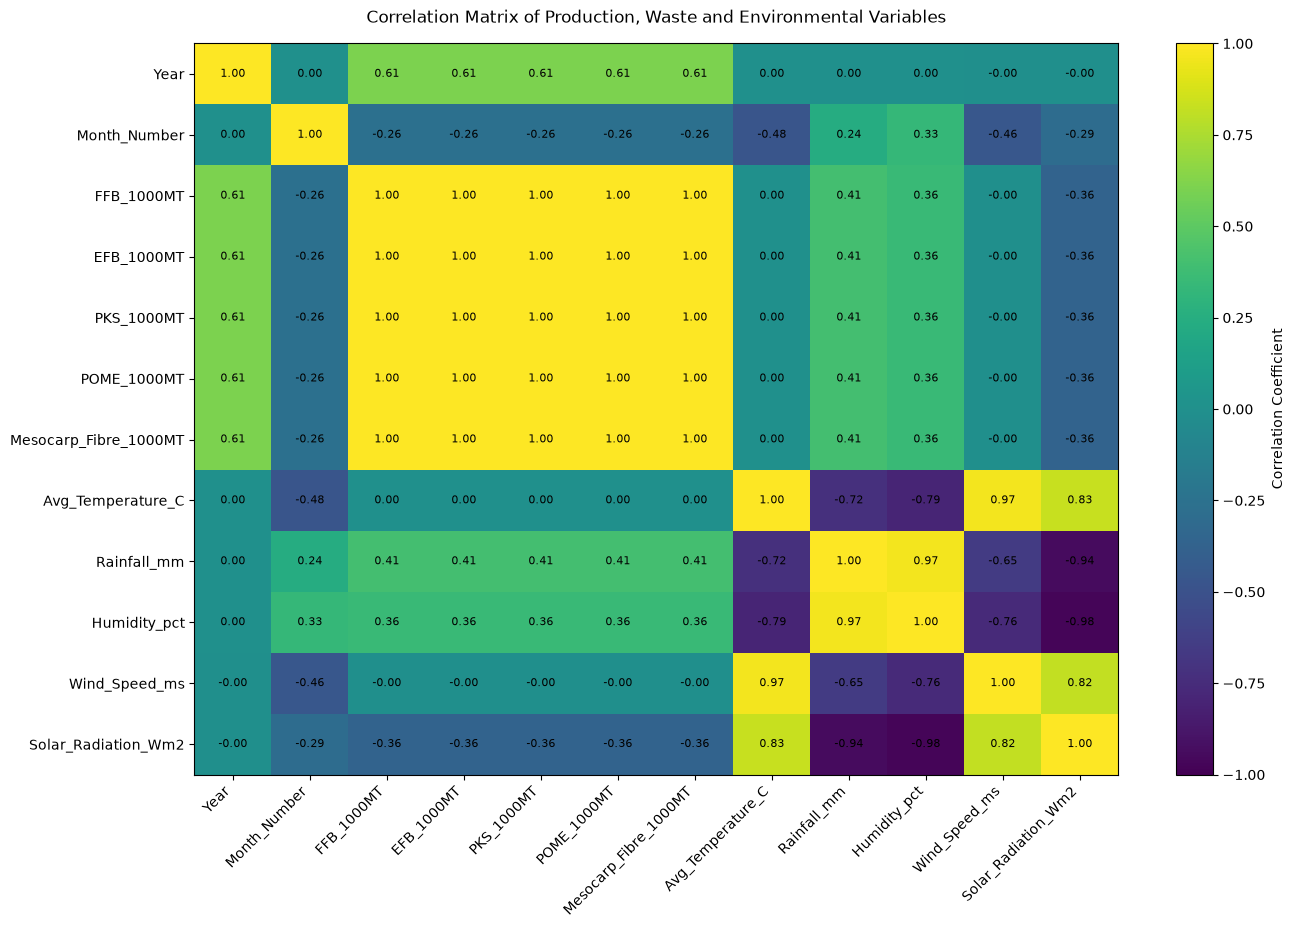

In [26]:
fig, ax = plt.subplots(figsize=(15, 10))

im = ax.imshow(
    correlation_matrix,
    vmin=-1,
    vmax=1,
    aspect="auto"
)

fig.colorbar(im, ax=ax, label="Correlation Coefficient")

ax.set_xticks(range(len(correlation_variables)))
ax.set_yticks(range(len(correlation_variables)))

ax.set_xticklabels(
    correlation_variables,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(correlation_variables)

# Add correlation values to each cell
for i in range(len(correlation_variables)):
    for j in range(len(correlation_variables)):
        ax.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

ax.set_title(
    "Correlation Matrix of Production, Waste and Environmental Variables",
    pad=15
)

plt.tight_layout()
plt.subplots_adjust(left=0.22, bottom=0.22)
plt.show()

### Key Correlation Findings

- FFB production and all four waste streams show near-perfect positive correlations (approximately 1.00). This reflects the conversion-factor relationships used to derive EFB, PKS, POME, and Mesocarp Fibre quantities from FFB production.
- Year shows a moderately strong positive correlation (approximately 0.61) with FFB and the waste quantities, consistent with the long-term upward production trend observed in the time-series analysis.
- Month number shows a negative correlation of approximately -0.26 with FFB and the waste quantities. However, the earlier monthly analysis demonstrates that the relationship is seasonal and non-linear, so this coefficient alone does not fully describe the monthly production pattern.
- Rainfall and humidity show moderate positive correlations with FFB and the waste quantities (approximately 0.41 and 0.36 respectively), while solar radiation shows a moderate negative correlation (approximately -0.36).
- Several environmental variables are strongly correlated with one another. For example, rainfall and humidity are strongly positively correlated (0.97), while humidity and solar radiation are strongly negatively correlated (-0.98).
- These environmental correlations should be interpreted cautiously because parts of the environmental dataset contain repeated monthly climatological profiles rather than independently observed year-specific weather measurements.

## 8. Environmental Data Assessment

The environmental variables are examined separately to assess their temporal behaviour and identify potential repetition in the historical climate profiles. This assessment is important because limited year-to-year variation in environmental predictors may affect their contribution to the predictive models.

In [27]:
climate_variables = [
    "Avg_Temperature_C",
    "Rainfall_mm",
    "Humidity_pct",
    "Wind_Speed_ms",
    "Solar_Radiation_Wm2"
]

df[climate_variables].describe().round(2)

,Avg_Temperature_C,Rainfall_mm,Humidity_pct,Wind_Speed_ms,Solar_Radiation_Wm2
count,732.00,732.00,732.00,732.00,732.00
mean,26.84,225.45,86.88,1.96,165.84
std,1.12,124.97,3.56,0.14,18.17
min,24.80,34.40,80.30,1.65,136.08
25%,25.82,103.20,83.38,1.85,148.65
50%,27.24,249.05,87.85,2.00,163.57
75%,27.72,334.12,90.20,2.06,183.11
max,28.70,456.70,92.10,2.27,198.14


In [28]:
annual_climate_profiles = (
    df.pivot(
        index="Year",
        columns="Month_Number",
        values=climate_variables
    )
)

print("Number of years:", len(annual_climate_profiles))
print(
    "Number of unique annual climate profiles:",
    len(annual_climate_profiles.drop_duplicates())
)

Number of years: 61
Number of unique annual climate profiles: 10


In [29]:
profile_groups = {}

for year in annual_climate_profiles.index:
    profile = tuple(annual_climate_profiles.loc[year].values)

    profile_groups.setdefault(profile, []).append(year)

repeated_profiles = [
    years
    for years in profile_groups.values()
    if len(years) > 1
]

repeated_profiles

[[1964,
  1965,
  1966,
  1967,
  1968,
  1969,
  1970,
  1971,
  1972,
  1973,
  1974,
  1975,
  1976,
  1977,
  1978,
  1979,
  1980,
  1981,
  1982,
  1983,
  1984,
  1985,
  1986,
  1987,
  1988,
  1989,
  1990,
  1991,
  1992,
  1993,
  1994,
  1995,
  1996,
  1997,
  1998,
  1999,
  2000,
  2001,
  2002,
  2003,
  2004,
  2005,
  2006,
  2007,
  2008,
  2009,
  2010,
  2011,
  2012,
  2013,
  2014,
  2024]]

### Environmental Data Limitation

The environmental data assessment identified 61 years of observations but only 12 unique annual climate profiles. Several years therefore share identical combinations of monthly temperature, rainfall, humidity, wind speed, and solar radiation values.

The repetition follows a systematic pattern across the historical period, indicating that the environmental variables do not represent independent year-specific meteorological observations for every year in the dataset.

Consequently, relationships involving the environmental predictors should be interpreted cautiously. The repeated profiles reduce the amount of independent temporal information available from these variables and may limit their contribution to model generalisation.

This represents an important limitation of the dataset and highlights the value of using independently observed year-specific meteorological data in future extensions of the analysis.

## 9. EDA Summary and Key Findings

The exploratory data analysis identified several important characteristics of the dataset:

- The dataset contains 732 complete monthly observations covering 1964–2024, with no missing values or duplicate year-month records.
- FFB production shows a clear long-term upward trend together with a pronounced recurring monthly pattern.
- POME represents the largest waste stream by quantity, followed by EFB, Mesocarp Fibre, and PKS.
- All four waste targets have near-perfect correlations with FFB because they were derived using approximately fixed conversion factors. This relationship must be considered when interpreting machine learning performance.
- Environmental variables show several strong correlations; however, further data-quality analysis identified only 12 unique annual climate profiles across 61 years. This limits the independent temporal information contained in these predictors.
- The combination of long-term trend and recurring monthly patterns supports the use of chronological validation rather than random train-test splitting.
- Model results that include FFB should be interpreted alongside a conversion-factor baseline and sensitivity analysis excluding FFB.

Overall, the EDA demonstrates that the dataset contains strong temporal structure and highly dependent target variables. These characteristics are important considerations for model development, validation, and interpretation.